<a href="https://colab.research.google.com/github/AvinashOraon123/ML_Projects/blob/main/Avinash_Neural_Network_Rail_Wheel_Contant_Analysis_for_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Initial Setup and Data Loading

This section handles the initial setup for the notebook, including:
- **Importing necessary libraries**: This includes common libraries for data manipulation (`pandas`, `numpy`), machine learning (`tensorflow`, `keras`, `sklearn`), and visualization (`matplotlib`).
- **Setting a random seed**: Ensures reproducibility of results across different runs.
- **Loading the dataset**: Reads data from an Excel file (`augmented_data_2.xlsx`) into a pandas DataFrame and then separates it into features (`x1`) and target variable (`y1`). The dimensions of these arrays are then printed.

In [ ]:
import random,os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler # For feature scaling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # For model evaluation
from sklearn.model_selection import train_test_split # For splitting data
from math import sqrt
from keras.models import Sequential # For building sequential neural networks
from keras.layers import Dense # For dense (fully connected) layers

In [ ]:
seed_value = 12321 # Set a seed for reproducibility across different libraries
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [ ]:
dataset1 = pd.read_excel('/content/Augmented_Data.xlsx') # Load data from Excel file
x1 = dataset1.iloc[:, 0:14].values # Extract features (input variables)
y1 = dataset1.iloc[:, 15].values # Extract target variable from column 15 (as indicated for WN)
print(len(x1))
print(len(x1[0]))
print(len(y1))
print(len(y1))

11920
14
11920
11920


### Neural Network for Regression Analysis

This notebook demonstrates the process of building and evaluating a Neural Network (NN) model for a regression task. The workflow includes data loading, preprocessing (splitting and scaling), model definition, training, and evaluation using various metrics.


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training (67%) and a temporary test set (33%)
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.33, random_state=42)
# Split the temporary test set into actual test (16.5%) and validation (16.5%) sets
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

In [ ]:
sc_x = StandardScaler() # Scaler for features
sc_y = StandardScaler() # Scaler for target variable

y_train = y_train.reshape((len(y_train),1)) # Reshape y arrays for consistent scaling
y_test = y_test.reshape((len(y_test),1))
y_val = y_val.reshape((len(y_val),1))
X_train = sc_x.fit_transform(x_train) # Scale training features
Y_train = sc_y.fit_transform(y_train) # Scale training target
X_val = sc_x.fit_transform(x_val)     # Scale validation features
Y_val = sc_y.fit_transform(y_val)     # Scale validation target
X_test = sc_x.fit_transform(x_test)   # Scale test features
Y_test = sc_y.fit_transform(y_test);   # Scale test target

Epoch 1/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1936 - val_loss: 0.0988
Epoch 2/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0888 - val_loss: 0.0795
Epoch 3/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0763 - val_loss: 0.0734
Epoch 4/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0685 - val_loss: 0.0636
Epoch 5/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0644 - val_loss: 0.0669
Epoch 6/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0612 - val_loss: 0.0616
Epoch 7/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0588 - val_loss: 0.0605
Epoch 8/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0542 - val_loss: 0.0549
Epoch 9/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0520 - val_loss: 0.0528
Epoch 10/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0509 - val_loss: 0.0537
Epoch 11/500
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0485 - val_loss: 0.0498
Epoch 12/500
267/267 ━━━━━━━━━━━━━━━━━━━━

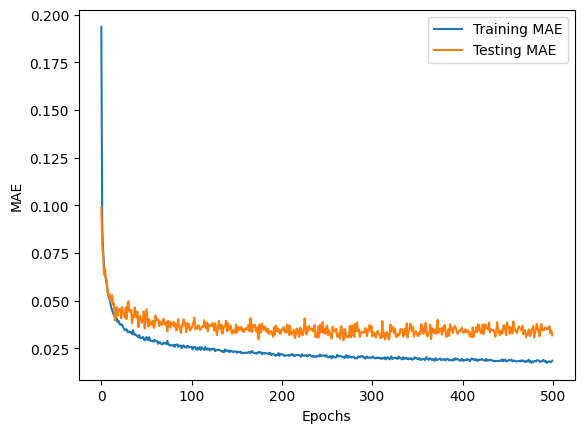

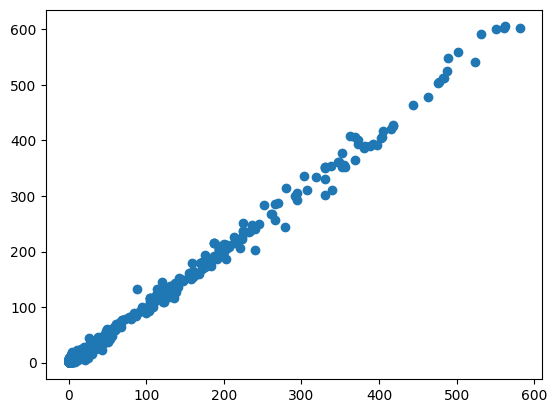

Training R2 Score: 0.9853389513181781
Testing R2 Score: 0.9940217991429927
[[6.59 4.84]
 [5.73 9.73]
 [2.62 0.45]
 ...
 [2.6  0.52]
 [2.07 2.37]
 [2.02 0.37]]


In [ ]:
from sklearn.model_selection import GridSearchCV

regressor = tf.keras.models.Sequential()
regressor.add(tf.keras.layers.Dense(units= 64, activation='relu')) # First hidden layer
regressor.add(tf.keras.layers.Dense(units= 36, activation='relu')) # Second hidden layer
regressor.add(tf.keras.layers.Dense(units= 24, activation='tanh')) # Third hidden layer
regressor.add(tf.keras.layers.Dense(units= 1)) # Output layer for regression
regressor.compile(optimizer = 'adam', loss = 'mae') # Compile model with Adam optimizer and MAE loss
history = regressor.fit(X_train, Y_train, batch_size = 30, epochs = 500, validation_data=(X_val, Y_val)) # Train the model

train_mae = history.history['loss']
test_mae = history.history['val_loss']

y_train_pred = sc_y.inverse_transform(regressor.predict(X_train)) # Inverse transform predictions to original scale
y_test_pred = sc_y.inverse_transform(regressor.predict(X_test))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

plt.plot(train_mae, label='Training MAE')
plt.plot(test_mae, label='Testing MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

plt.scatter(y_test, y_test_pred)
plt.show()
print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)


regressor.save('model1_WN_.keras') # Save the trained Keras model
np.set_printoptions(precision=2)
print(np.concatenate((y_test_pred.reshape(len(y_test_pred),1), y_test.reshape(len(y_test),1)),1)) # Display predicted vs actual values

### Evaluation Metrics

This section computes and displays several key evaluation metrics for the trained regression model:

-   **R-squared (R2 Score)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 score (closer to 1) indicates a better fit of the model to the data.
-   **Root Mean Squared Error (RMSE)**: Measures the average magnitude of the errors. It is the square root of the average of the squared differences between prediction and actual observation. A lower RMSE indicates a better model fit.
-   **Mean Absolute Error (MAE)**: Measures the average of the absolute differences between predictions and actual observations. It provides a straightforward measure of prediction accuracy, where a lower MAE indicates better performance.

In [ ]:
mape = tf.keras.losses.MeanAbsolutePercentageError()

y_fricDispL_pred=[] # List for predicted friction displacement
y_fricDispL_test =[] # List for actual friction displacement
y_contLocL_pred=[]
y_contLocL_test =[]
y_derailL_pred =[]
y_derailL_test =[]
y_normLoadL_pred =[]
y_normLoadL_test =[]

# Assuming `y_test_pred` holds the model's test predictions
for i in range(len(y_test_pred)):
  y_fricDispL_pred.append(y_test_pred[i])
  y_fricDispL_test.append(y_test[i])

from sklearn.metrics import r2_score
print('Fric_power')
print('r2_score: ',r2_score( y_fricDispL_test, y_fricDispL_pred))

from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error( y_fricDispL_test, y_fricDispL_pred)) # Calculate Root Mean Squared Error
print('rmse: ',rmse)

from sklearn.metrics import mean_absolute_error
print('mean_absolute_error: ',mean_absolute_error( y_fricDispL_test, y_fricDispL_pred)) # Calculate Mean Absolute Error

Fric_power
r2_score:  0.9940217991429927
rmse:  5.875097306252653
mean_absolute_error:  3.1276313603952772


### Saving Model Output

In [ ]:
from google.colab import files
from datetime import datetime
import pandas as pd
import numpy as np

case = 'test'

# Create a DataFrame from the predicted and actual values
# Assuming y_test_pred and y_test are numpy arrays or lists from previous steps
data_to_save = pd.DataFrame({
    'y_test_pred': np.array(y_test_pred).flatten(),
    'y_test': np.array(y_test).flatten()
})

now = datetime.now()
today = now.strftime("%m_%d_%Y_%H_%M_%S")
file_name = "ML_output_y_"+ case + today + ".xlsx"
writer = pd.ExcelWriter(file_name) # Create an Excel writer with a timestamped filename
data_to_save.to_excel(writer, sheet_name= case + 'ing_output', index=False) # Save the DataFrame to Excel
writer.close() # Close the writer to finalize the Excel file

files.download(file_name) # Trigger download of the created Excel file

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>